In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from init_env import set_project_root
project_root = set_project_root()
os.chdir(project_root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# Performance Profiles

Total unique problems: 12
Method BFGS: Solved 12 problems.
Method BFGS: Final percentage at 1000 iterations: 100.00%
Method BFGSW: Solved 12 problems.
Method BFGSW: Final percentage at 1000 iterations: 100.00%
Method DFP: Solved 6 problems.
Method DFP: Final percentage at 1000 iterations: 50.00%
Method DFPW: Solved 5 problems.
Method DFPW: Final percentage at 1000 iterations: 41.67%
Method GradientDescent,: Solved 9 problems.
Method GradientDescent,: Final percentage at 1000 iterations: 75.00%
Method GradientDescentW: Solved 9 problems.
Method GradientDescentW: Final percentage at 1000 iterations: 75.00%
Method Newton: Solved 12 problems.
Method Newton: Final percentage at 1000 iterations: 100.00%
Method NewtonW: Solved 12 problems.
Method NewtonW: Final percentage at 1000 iterations: 100.00%
Method TRNewtonCG: Solved 11 problems.
Method TRNewtonCG: Final percentage at 1000 iterations: 91.67%
Method TRSR1CG: Solved 11 problems.
Method TRSR1CG: Final percentage at 1000 iterations: 91.67

C:\Users\hvand\AppData\Local\Temp\ipykernel_26120\213848990.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(methods))


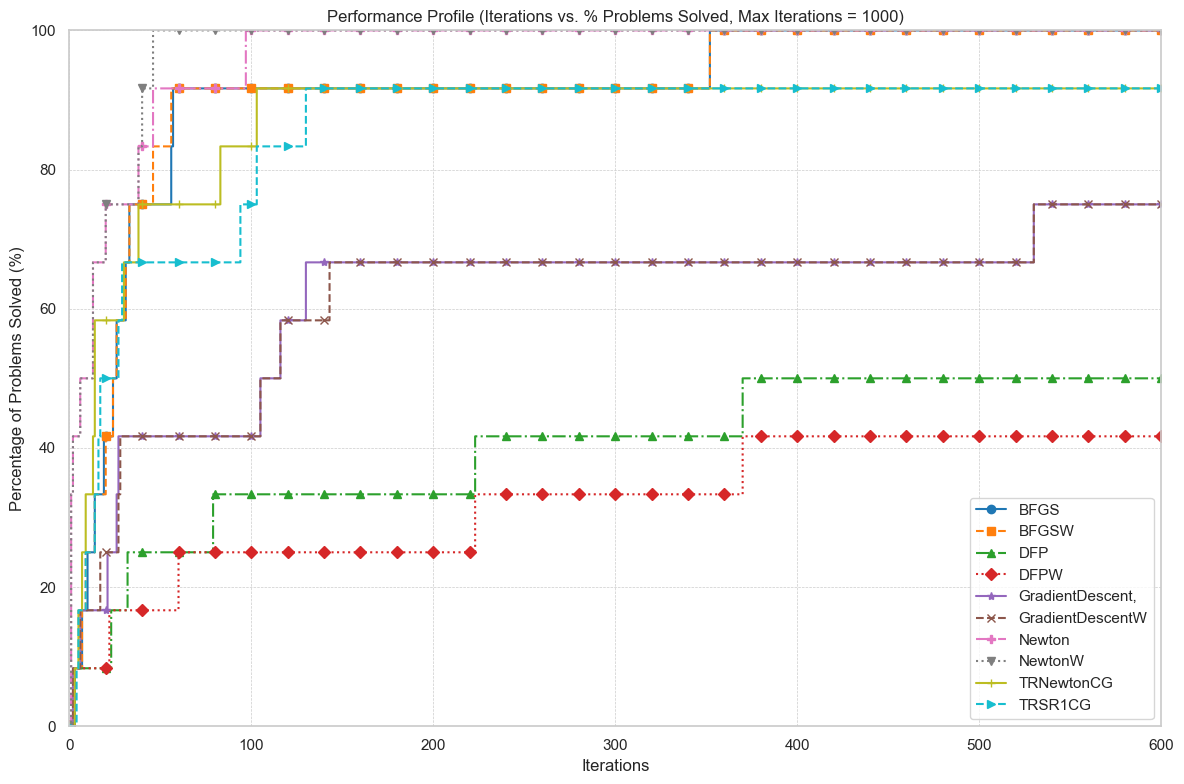

In [6]:
# Load the dataframe.
df = pd.read_csv('results.csv')

# Ensure 'convergence' is boolean
df['convergence'] = df['convergence'].astype(bool)

# Filter for converged runs
converged_df = df[df['convergence']].copy()

# Find the minimum iterations for each problem-method pair that converged
min_iterations_df = converged_df.loc[converged_df.groupby(['problem', 'method'])['iterations'].idxmin()]

# Get the set of all unique problems present in the original data
all_problems = df['problem'].unique()
n_problems_total = len(all_problems)
print(f"Total unique problems: {n_problems_total}")

# Define the maximum number of iterations for the plot
max_iter = 1000
iteration_thresholds = np.arange(1, max_iter + 1) # Iteration values for x-axis

methods = sorted(min_iterations_df['method'].unique()) # Sort methods for consistent legend order

# Setup
plt.figure(figsize=(12, 8))  # Bigger figure
styles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
markers = ['o', 's', '^', 'D', '*', 'x', 'P', 'v', '+', '>']
colors = cm.get_cmap('tab10', len(methods))

# Plot each method
for i, method in enumerate(methods):
    method_df = min_iterations_df[min_iterations_df['method'] == method]
    solved_iterations = method_df['iterations'].values

    cumulative_solved_count = [np.sum(solved_iterations <= t) for t in iteration_thresholds]
    percentage_solved = [(count / n_problems_total) * 100 for count in cumulative_solved_count]

    plot_iterations = np.insert(iteration_thresholds, 0, 0)
    plot_percentage = np.insert(np.array(percentage_solved), 0, 0.0)

    plt.plot(plot_iterations, plot_percentage,
             label=method,
             drawstyle='steps-post',
             linestyle=styles[i % len(styles)],
             marker=markers[i % len(markers)],
             markevery=20,
             color=colors(i))

    print(f"Method {method}: Solved {method_df.shape[0]} problems.")
    print(f"Method {method}: Final percentage at {max_iter} iterations: {percentage_solved[-1]:.2f}%")

# Configure plot
plt.title(f'Performance Profile (Iterations vs. % Problems Solved, Max Iterations = {max_iter})')
plt.xlabel('Iterations')
plt.ylabel('Percentage of Problems Solved (%)')
plt.xlim(0, 600)     # Focused on interesting region
plt.ylim(0, 100)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Legend outside
plt.legend()

plt.tight_layout()   # Fit everything nicely
plt.show()

# Table

In [7]:
def plotTable(df, values, title):
    all_problems = sorted(df['problem'].unique())
    all_methods = sorted(df['method'].unique())

    # --- Create Pivot for Iterations ---
    pivot = df.pivot_table(index='problem', columns='method', values=values)
    pivot = pivot.reindex(index=all_problems, columns=all_methods) # Ensure all included

    # --- Create Pivot for Convergence (for styling) ---
    convergence_pivot = df.pivot_table(index='problem', columns='method', values='convergence')
    convergence_pivot = convergence_pivot.reindex(index=all_problems, columns=all_methods)

    # --- Styling Function ---
    def style_table(data_df):
        # Create a style DataFrame based on convergence_pivot
        style_df = pd.DataFrame('', index=data_df.index, columns=data_df.columns)
        success_color = 'background-color: lightgreen'
        fail_color = 'background-color: lightcoral'
        missing_color = 'background-color: lightgray'
        for problem in data_df.index:
            for method in data_df.columns:
                # Check if the method exists in convergence_pivot columns
                if method not in convergence_pivot.columns:
                    style_df.loc[problem, method] = missing_color
                    continue
                status = convergence_pivot.loc[problem, method]
                if pd.isna(status): style_df.loc[problem, method] = missing_color
                elif status: style_df.loc[problem, method] = success_color
                else: style_df.loc[problem, method] = fail_color
        return style_df

    # --- Apply Styling ---
    styled_iterations = pivot.style \
        .apply(style_table, axis=None) \
        .format("{:.0f}", na_rep='-') \
        .set_caption(f"Table: {title} Summary") \
        .set_properties(**{
            'border': '1px solid black',
            'color': 'black'  # <-- Explicitly set text color to black
        })
    
    if values == 'cpu_seconds':
        styled_iterations = styled_iterations.format("{:.3f}s", na_rep='-')

    # --- Display/Save ---
    # To display in Jupyter Notebook or similar:
    # from IPython.display import display
    display(styled_iterations)

In [8]:
plotTable(df, 'iterations', 'Iterations')

method,BFGS,BFGSW,DFP,DFPW,"GradientDescent,",GradientDescentW,Newton,NewtonW,TRNewtonCG,TRSR1CG
problem,,,,,,,,,,
datafit_2,14,14,79,60,530,530,6,6,7,27
exponential_10,19,20,1000,1000,27,27,13,13,13,16
exponential_100,10,9,1000,1000,21,17,13,13,14,29
genhumps_5,57,46,1000,1000,130,143,97,40,83,130
quad_1000_10,31,31,370,370,116,116,1,1,9,9
quad_1000_1000,352,352,1000,1000,1000,1000,1,1,103,103
quad_10_10,26,26,223,223,105,105,1,1,5,5
quad_10_1000,56,56,1000,1000,1000,1000,1,1,14,14
quartic_1,3,3,3,3,2,2,2,2,3,4


In [9]:
plotTable(df, 'f_evals', 'Function Evaluations')

method,BFGS,BFGSW,DFP,DFPW,"GradientDescent,",GradientDescentW,Newton,NewtonW,TRNewtonCG,TRSR1CG
problem,,,,,,,,,,
datafit_2,6982,7019,7228,7400,3438,6876,6889,6902,6917,6945
exponential_10,311,362,36300,65252,69,138,182,226,253,270
exponential_100,260,288,36058,64877,45,89,133,177,206,236
genhumps_5,1613,1744,37677,66624,376,837,1052,1200,1343,1474
quad_1000_10,564,627,1368,2109,233,466,469,472,491,501
quad_1000_1000,6206,6911,8912,10913,2001,5184,5187,5190,5397,5501
quad_10_10,498,551,998,1445,211,422,425,428,439,445
quad_10_1000,5359,5472,7473,9474,2001,5196,5199,5202,5231,5246
quartic_1,39,46,53,60,5,10,15,20,27,32


In [10]:
plotTable(df, 'grad_evals', 'Gradient Evaluations')

method,BFGS,BFGSW,DFP,DFPW,"GradientDescent,",GradientDescentW,Newton,NewtonW,TRNewtonCG,TRSR1CG
problem,,,,,,,,,,
datafit_2,1652,1681,1761,1882,531,1592,1599,1612,1620,1637
exponential_10,174,216,1217,2220,28,83,97,124,138,154
exponential_100,145,165,1166,2174,22,58,72,99,114,134
genhumps_5,809,905,1906,2909,131,421,519,611,671,751
quad_1000_10,407,470,841,1582,117,350,352,355,365,375
quad_1000_1000,3765,4470,5471,7472,1001,3199,3201,3204,3308,3412
quad_10_10,361,414,638,1085,106,317,319,322,328,334
quad_10_1000,3293,3406,4407,6408,1001,3201,3203,3206,3221,3236
quartic_1,29,36,40,47,3,8,11,16,20,25


In [11]:
plotTable(df, 'cpu_seconds', 'CPU Time (seconds)')

method,BFGS,BFGSW,DFP,DFPW,"GradientDescent,",GradientDescentW,Newton,NewtonW,TRNewtonCG,TRSR1CG
problem,,,,,,,,,,
datafit_2,0.001s,0.002s,0.005s,0.004s,0.035s,0.048s,0.001s,0.001s,0.001s,0.001s
exponential_10,0.001s,0.002s,0.381s,0.330s,0.001s,0.001s,0.017s,0.002s,0.002s,0.002s
exponential_100,0.005s,0.005s,1.359s,1.062s,0.002s,0.003s,0.004s,0.004s,0.003s,0.005s
genhumps_5,0.006s,0.006s,0.578s,0.458s,0.008s,0.015s,0.024s,0.012s,0.012s,0.020s
quad_1000_10,6.146s,7.039s,73.934s,89.337s,12.699s,17.035s,0.296s,0.325s,1.714s,1.259s
quad_1000_1000,65.551s,79.030s,165.912s,196.274s,116.630s,201.013s,0.282s,0.311s,18.646s,11.511s
quad_10_10,0.070s,0.074s,0.421s,0.421s,0.241s,0.329s,0.005s,0.009s,0.016s,0.008s
quad_10_1000,0.078s,0.118s,1.396s,1.870s,1.390s,2.468s,0.003s,0.003s,0.032s,0.019s
quartic_1,0.000s,0.001s,0.000s,0.000s,0.000s,0.001s,0.000s,0.000s,0.001s,0.000s


# Big Question

In [2]:
import seaborn as sns
sns.set_theme(style="whitegrid")
df = pd.read_csv('lbfgs_memory_experiment_results.csv')


--- Analyzing Problem: quad_10_10 ---


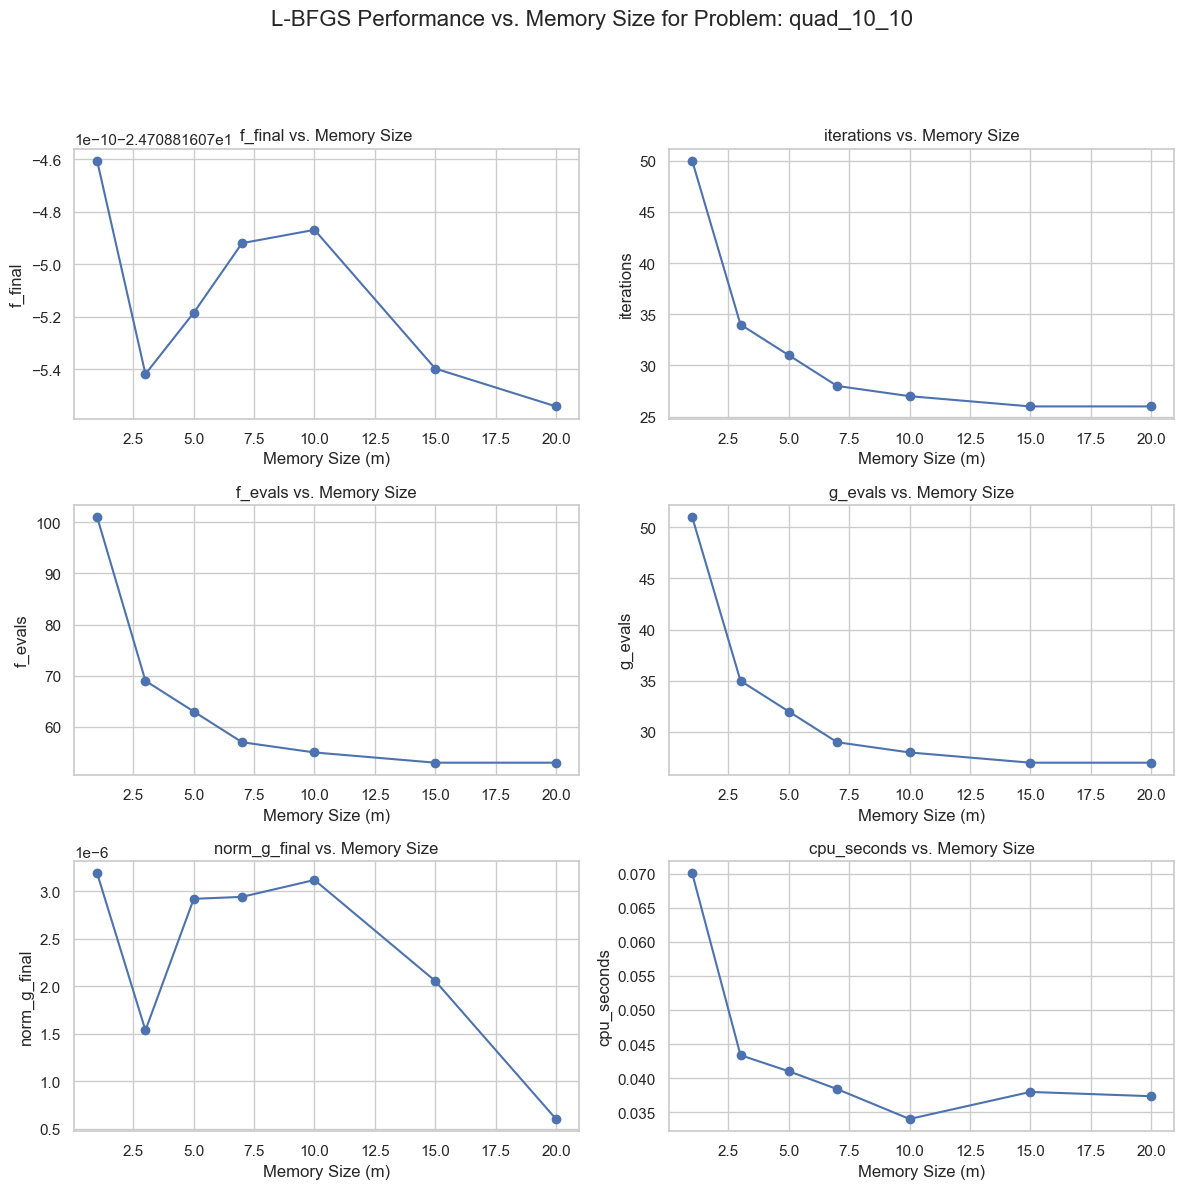


--- Analyzing Problem: quad_10_1000 ---


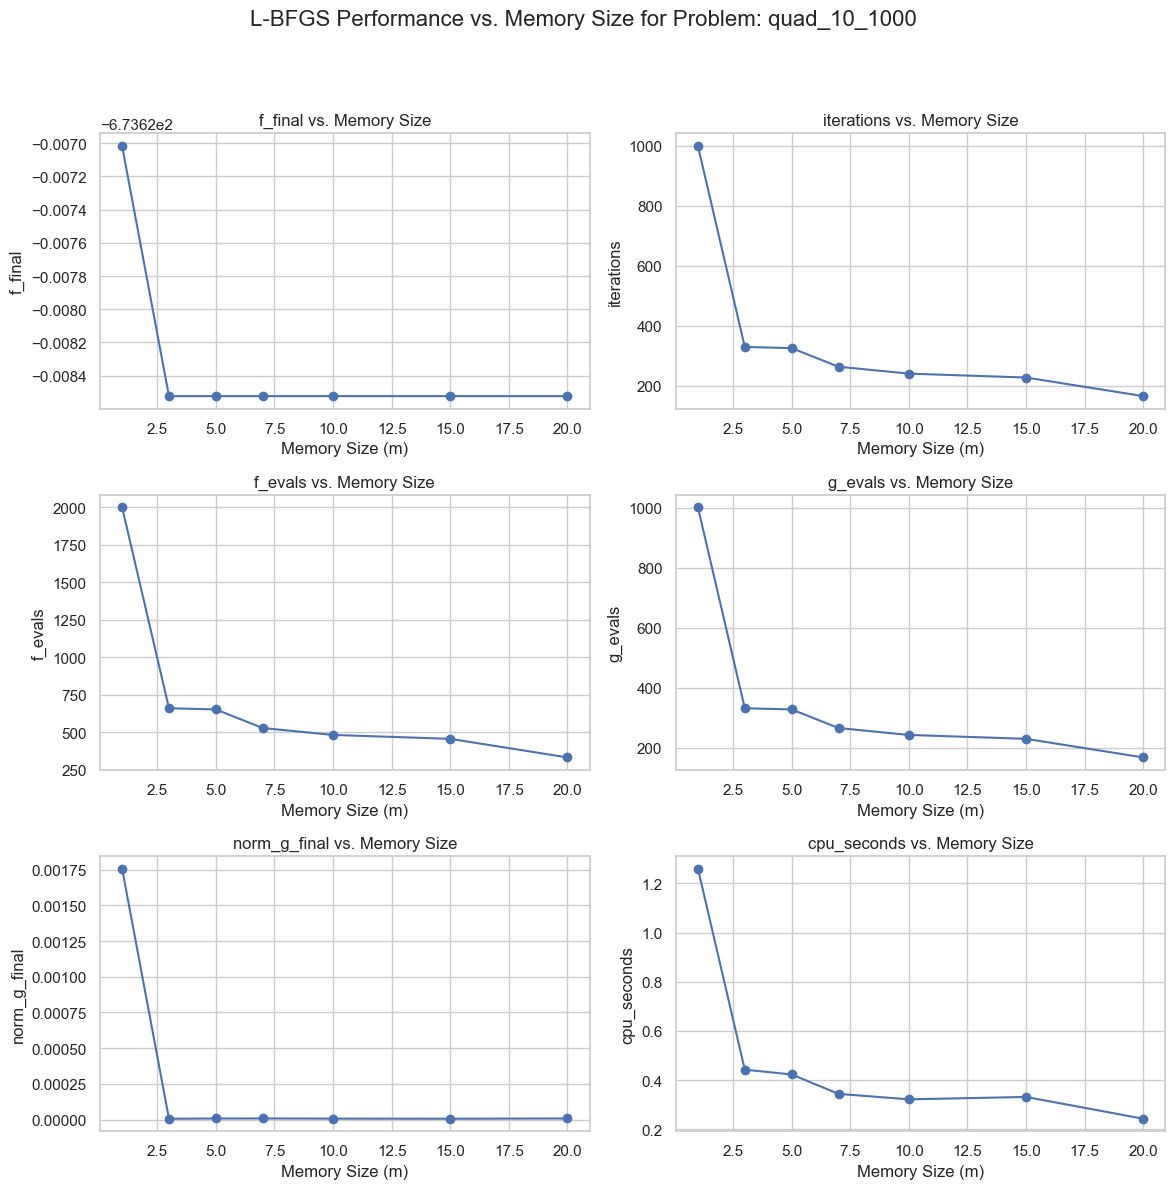


--- Analyzing Problem: quad_1000_10 ---


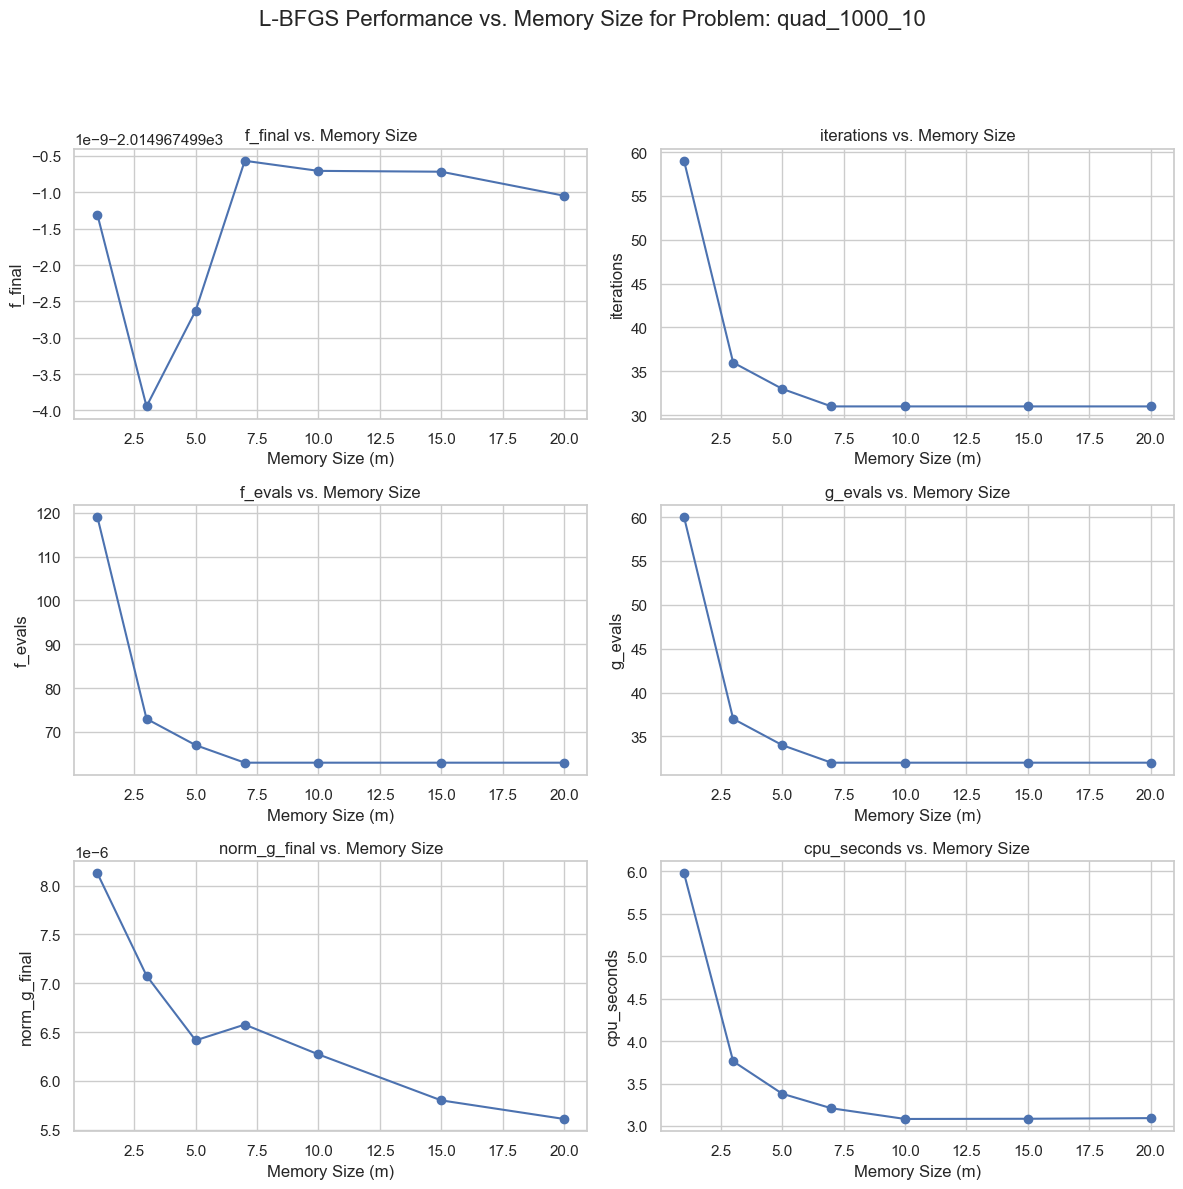


--- Analyzing Problem: quad_1000_1000 ---


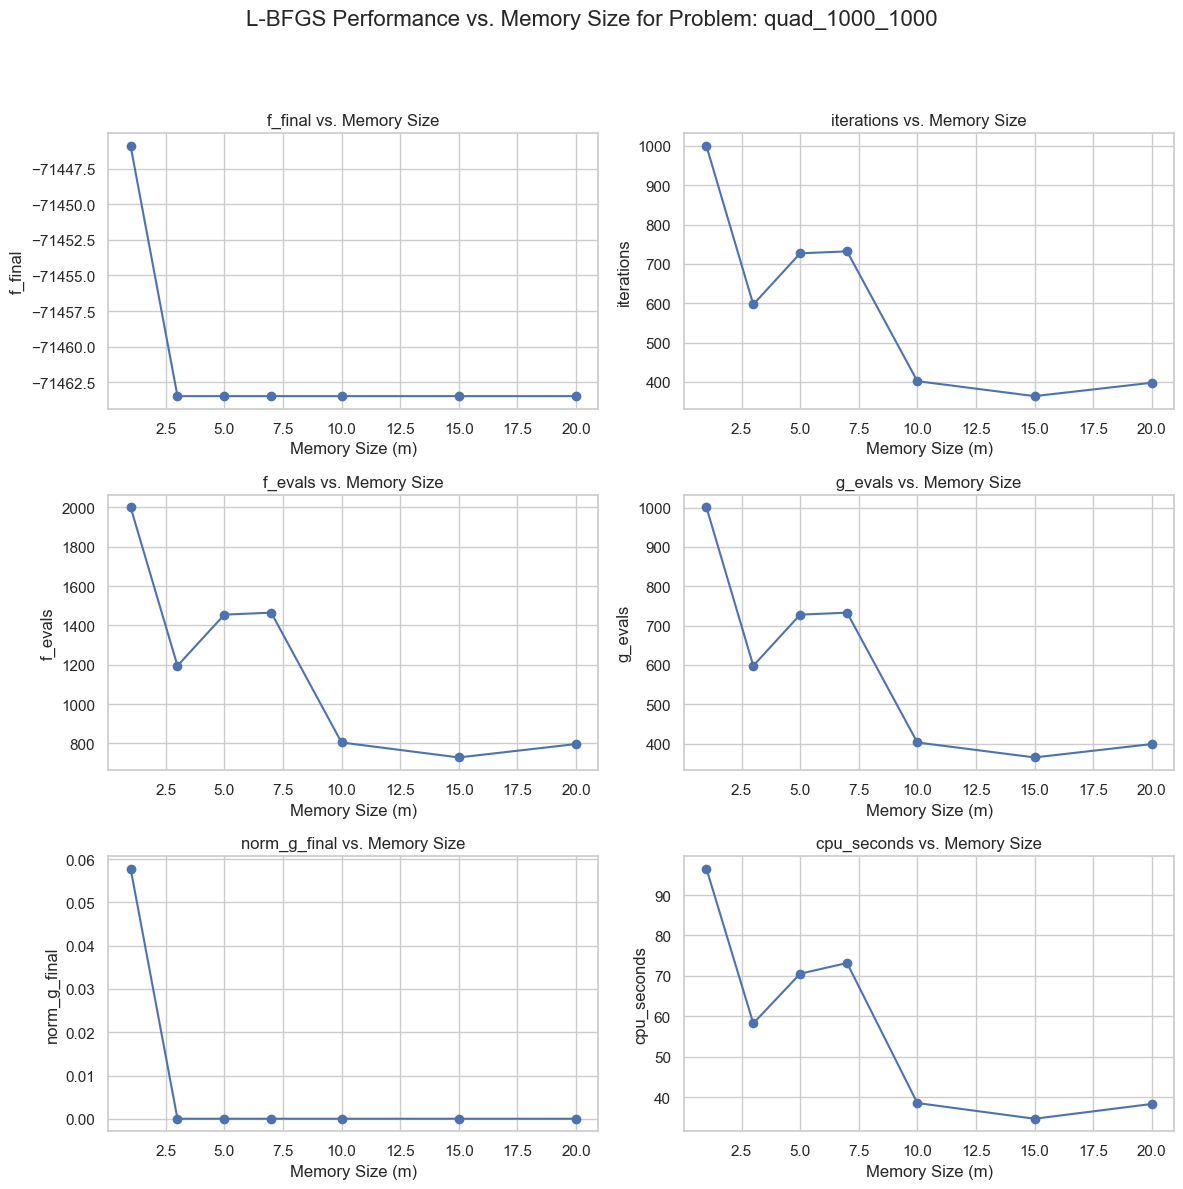


--- Analyzing Problem: quartic_1 ---


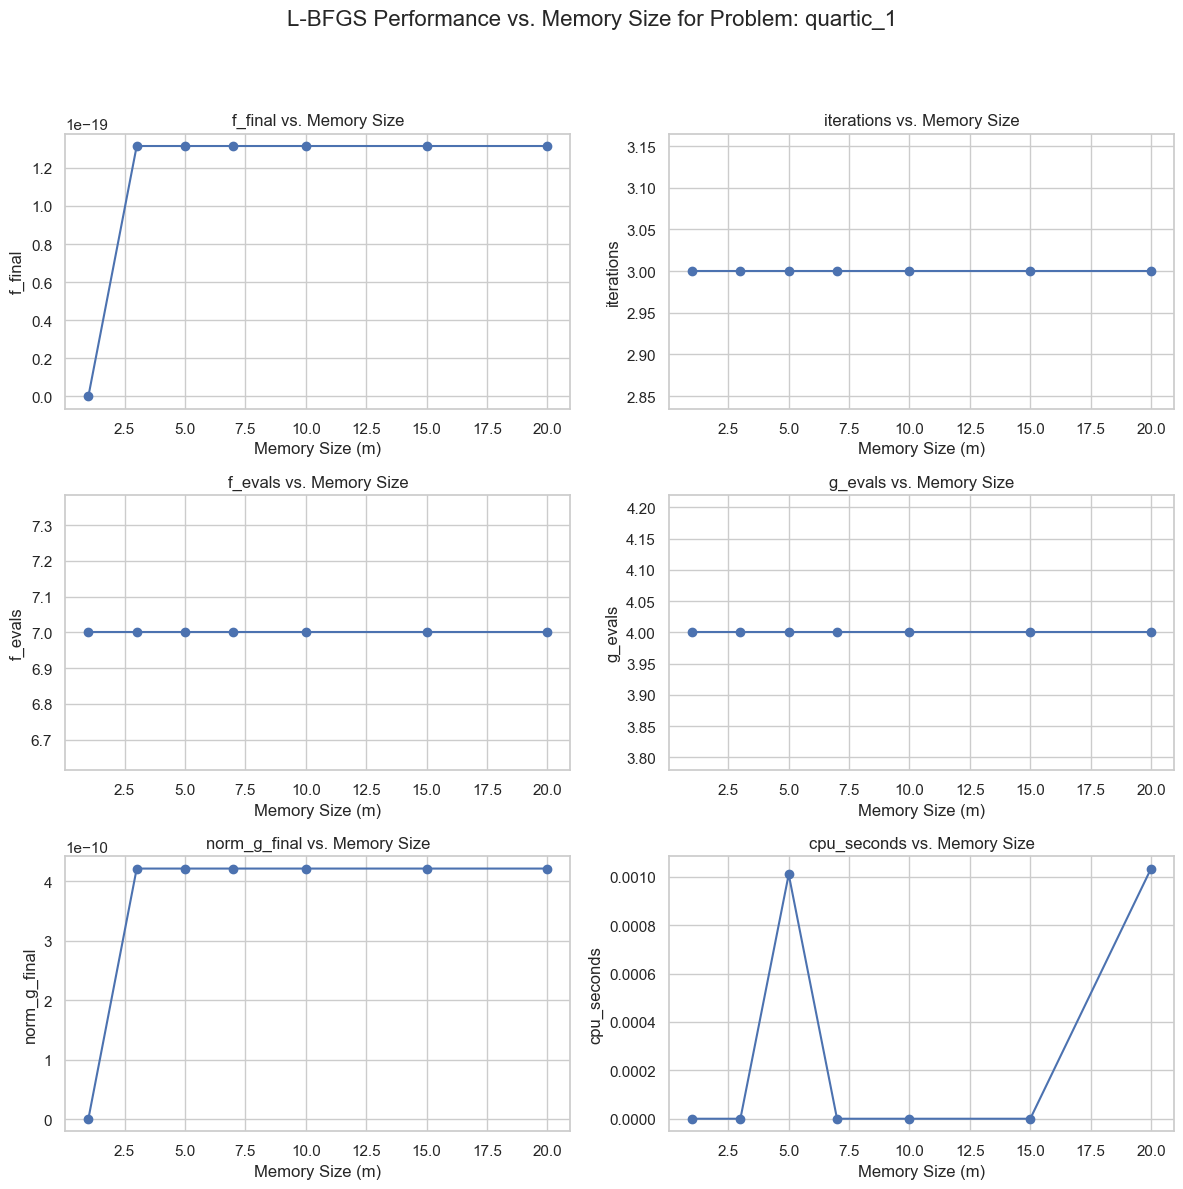


--- Analyzing Problem: quartic_2 ---


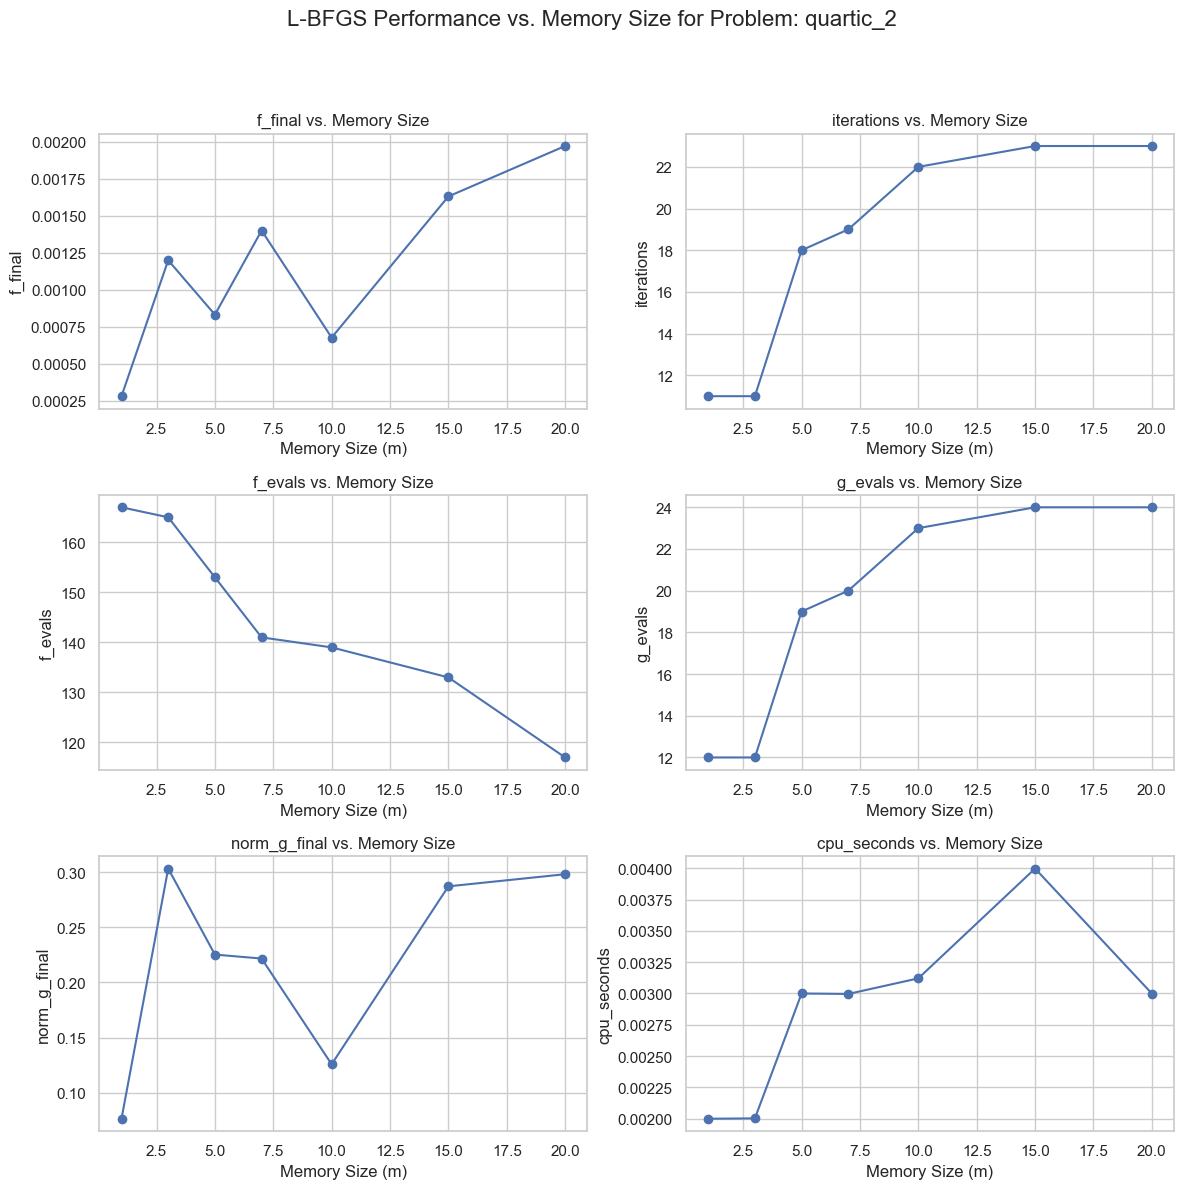


--- Analyzing Problem: rosenbrock_2 ---


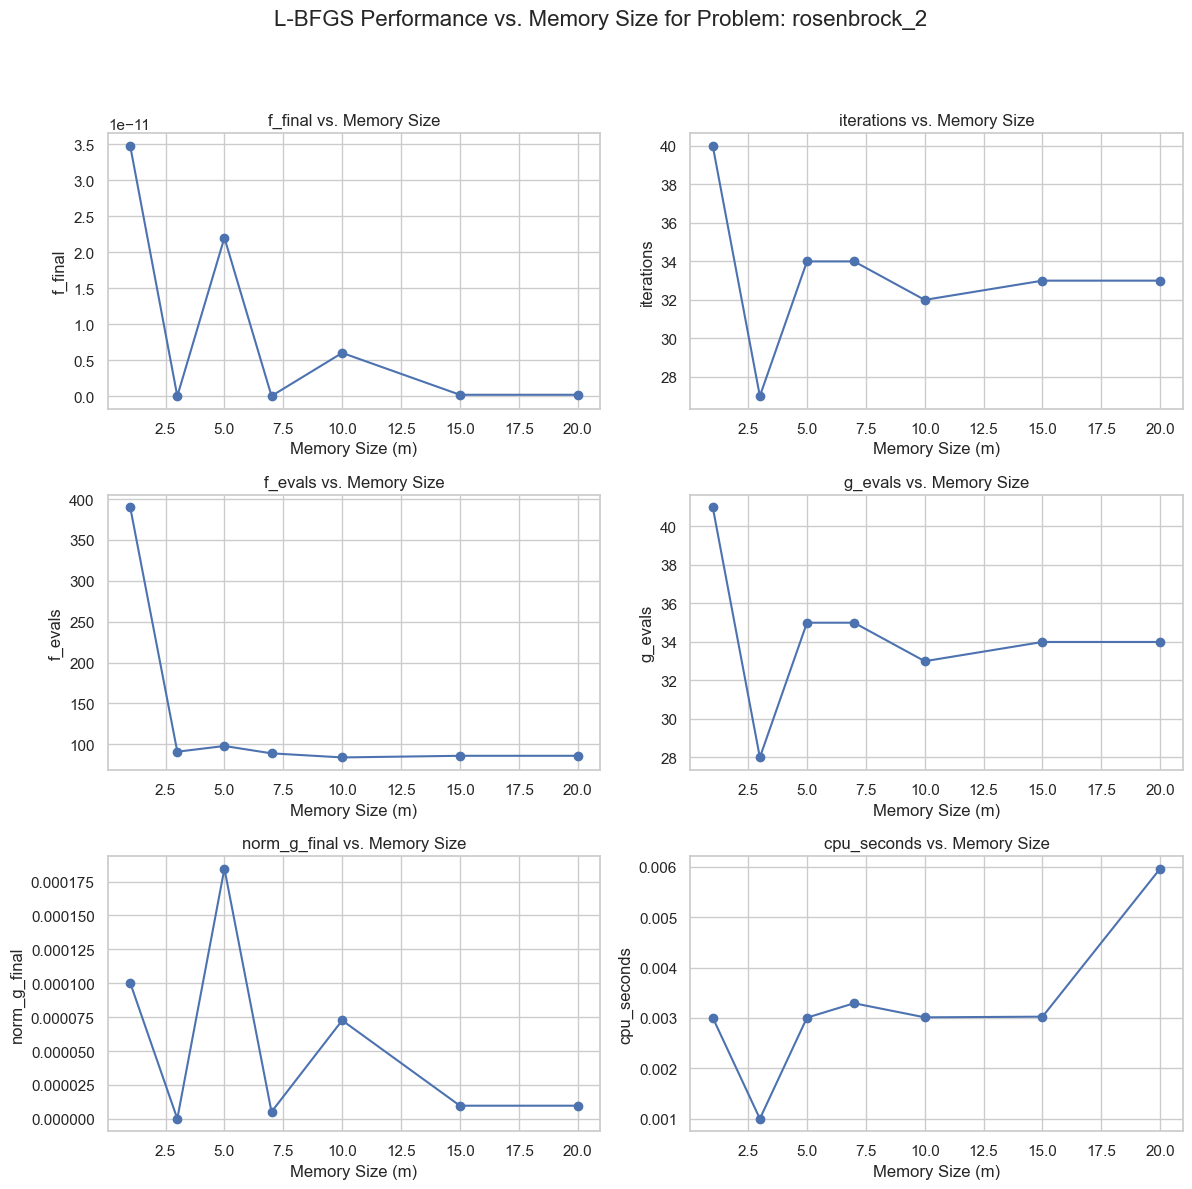


--- Analyzing Problem: rosenbrock_100 ---


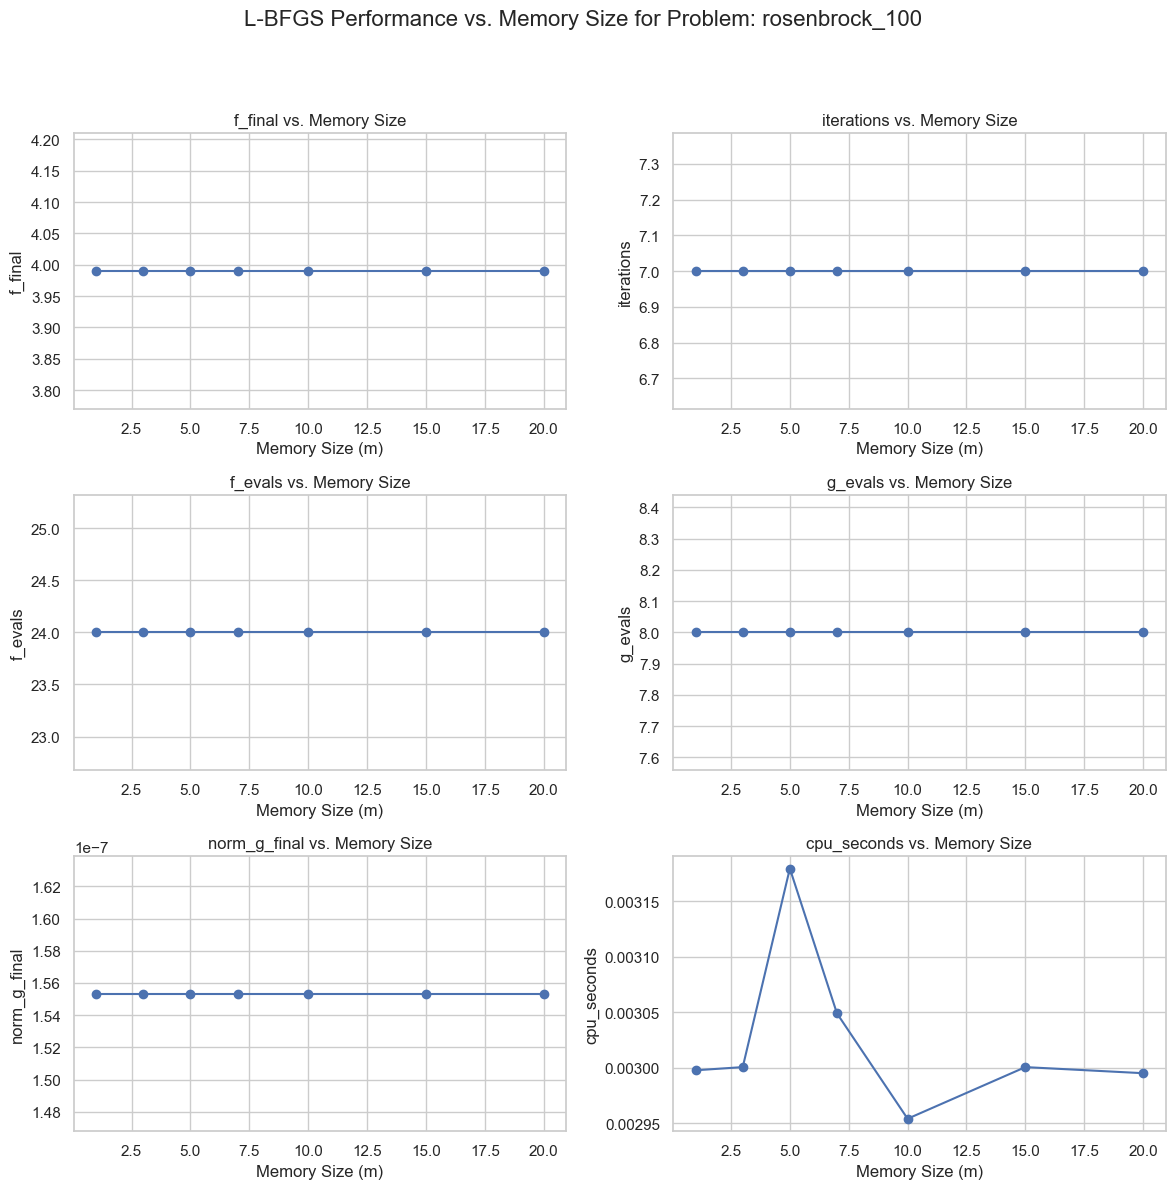


--- Analyzing Problem: datafit_2 ---


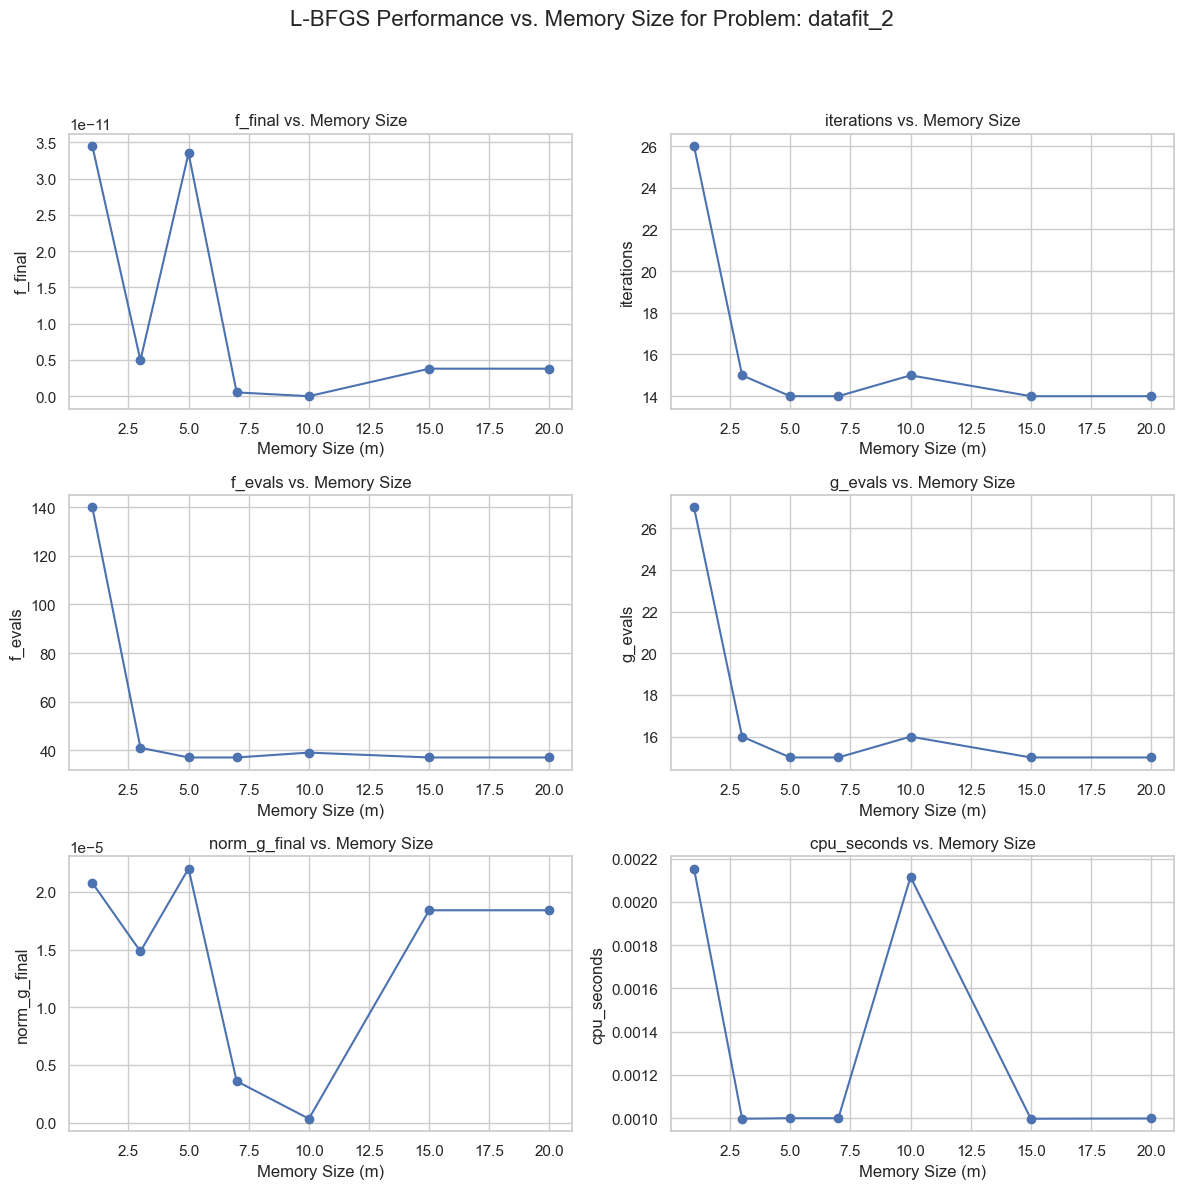


--- Analyzing Problem: exponential_10 ---


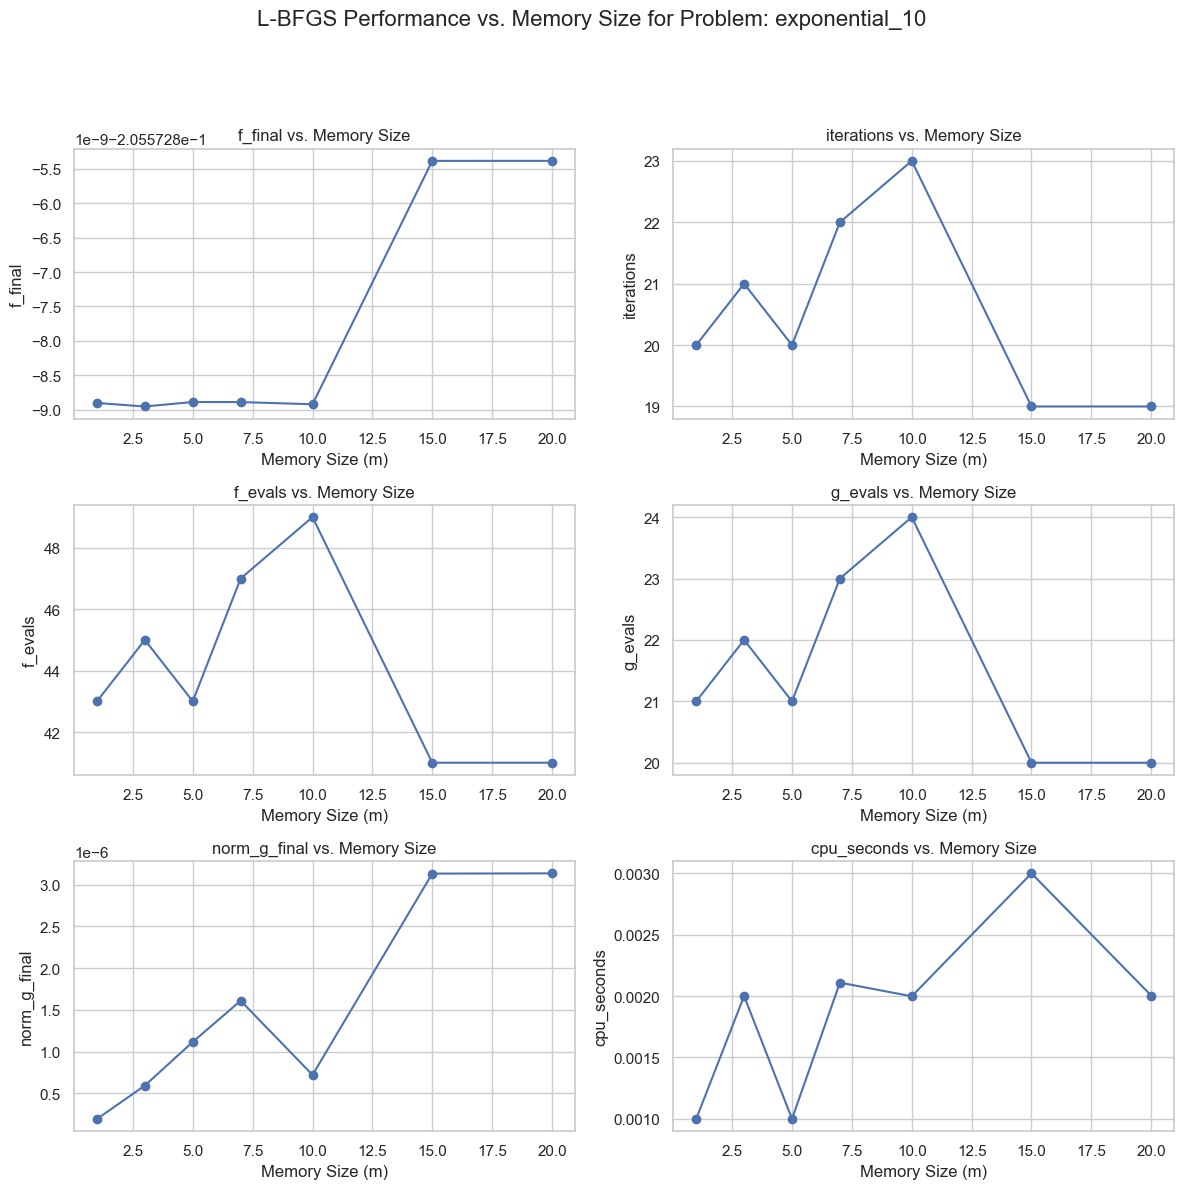


--- Analyzing Problem: exponential_100 ---


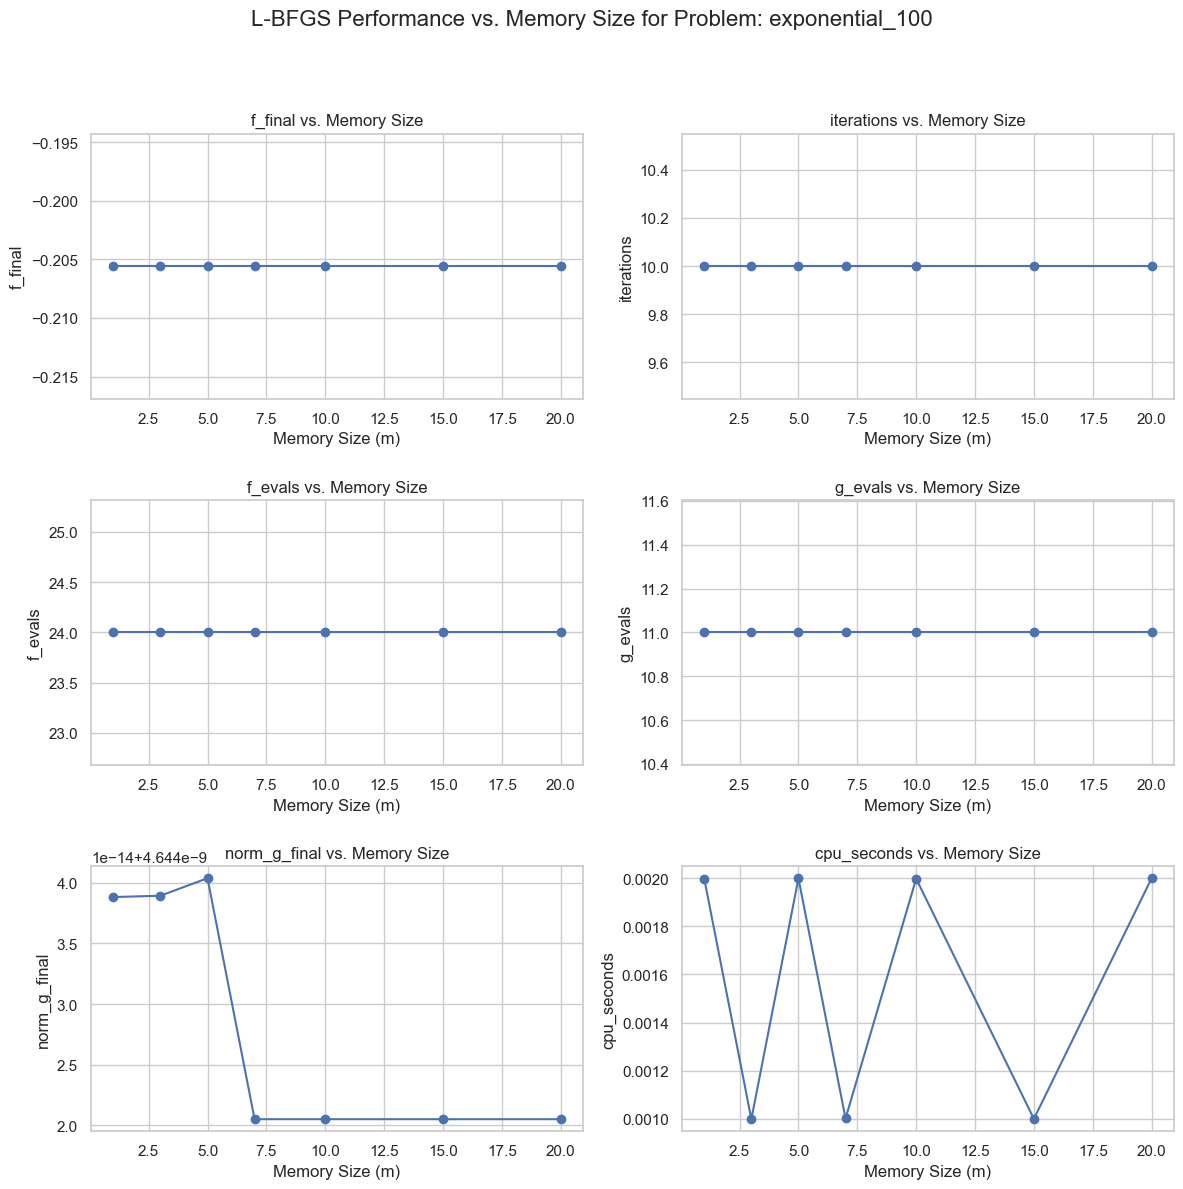


--- Analyzing Problem: genhumps_5 ---


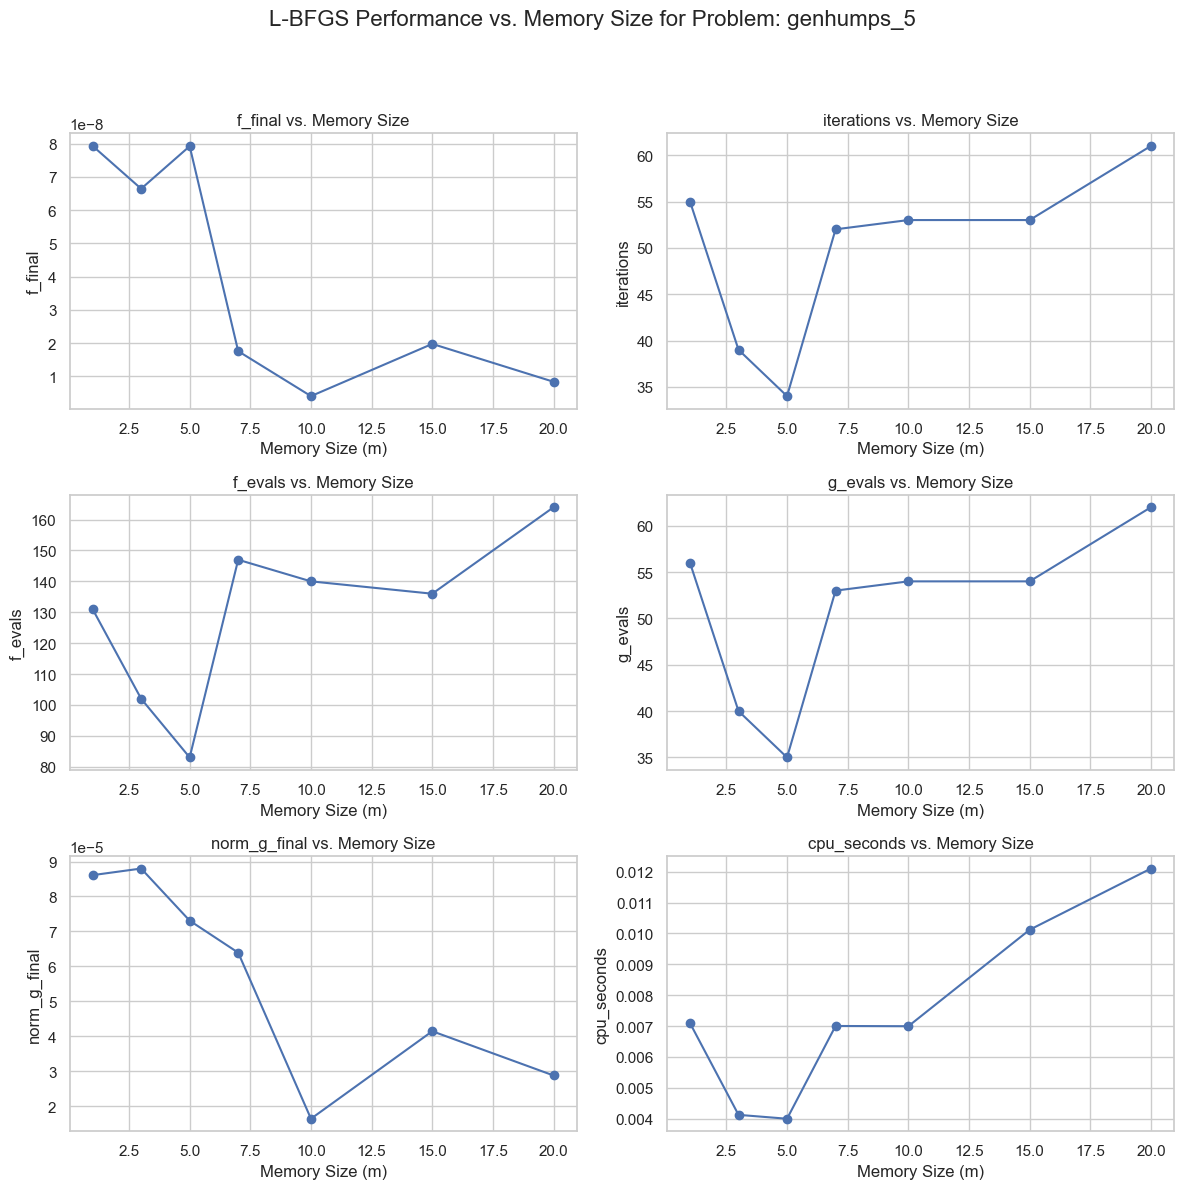

In [ ]:
# List of metrics
metrics_to_plot = ['f_final', 'iterations', 'f_evals', 'g_evals', 'norm_g_final', 'cpu_seconds']

problems = df['problem'].unique()

for problem_name in problems:
    print(f"\n--- Analyzing Problem: {problem_name} ---")

    # Filter data for the current problem
    problem_df = df[df['problem'] == problem_name].copy()

    # Sort by memory size for plotting lines correctly
    problem_df.sort_values(by='memory_size', inplace=True)

    # Create plots for each metric
    n_metrics = len(metrics_to_plot)
    n_cols = 2 # Adjust as desired
    n_rows = (n_metrics + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
    axes = axes.flatten()

    fig.suptitle(f'L-BFGS Performance vs. Memory Size for Problem: {problem_name}', fontsize=16, y=1.02)

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        if metric in problem_df.columns:
            ax.plot(problem_df['memory_size'], problem_df[metric], marker='o', linestyle='-')

            ax.set_title(f'{metric} vs. Memory Size')
            ax.set_xlabel('Memory Size (m)')
            ax.set_ylabel(metric)

        else:
            ax.set_title(f'{metric} (Not Found)')
            ax.axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()